In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy

# Concatenate individual files:

In [5]:
samples = ["GSM7454068_V350003741_L01_81", "GSM7454069_V350003741_L01_82", "GSM7454070_V350003741_L01_83",
          "GSM7454071_V350003741_L01_84", "GSM7454072_V350003741_L01_85", "GSM7454073_V350003741_L01_86",
          "GSM7454074_V350003741_L01_87", "GSM7454075_V350003741_L01_88", "GSM7454076_V350003741_L01_73"]

In [6]:
for metric in ["clustering_coefs", "degree_centralities", "degrees", "network_metrics", "node_bcs"]:
    metric_df = pd.DataFrame()
    for sample in samples:
        current = pd.read_csv("metrics_data/"+metric+"_"+sample+"_0_network.csv")
        metric_df = pd.concat([metric_df, current], ignore_index=True)
    metric_df.to_csv("metrics_data/data/"+metric+".csv", index=False)

In [7]:
for metric in ["clustering_coefs", "degrees", "network_metrics", "node_bcs"]:
    metric_df = pd.DataFrame()
    for sample in samples:
        current = pd.read_csv("metrics_data/"+metric+"_"+sample+"_network_weighted.csv")
        metric_df = pd.concat([metric_df, current], ignore_index=True)
    metric_df.to_csv("metrics_data/data/"+metric+"_weighted.csv", index=False)

In [9]:
samples = ["g-1 ", "g-3", "g-4", "g-5", "g-6", "g-7", "g-8", "g-9"]

In [10]:
for metric in ["clustering_coefs", "degree_centralities", "degrees", "network_metrics", "node_bcs"]:
    metric_df = pd.DataFrame()
    for sample in samples:
        current = pd.read_csv("metrics_data/protein_"+metric+"_protein_"+sample+"_network.csv")
        metric_df = pd.concat([metric_df, current], ignore_index=True)
    metric_df.to_csv("metrics_data/data/protein_"+metric+".csv", index=False)

In [11]:
for metric in ["clustering_coefs", "degrees", "network_metrics", "node_bcs"]:
    metric_df = pd.DataFrame()
    for sample in samples:
        current = pd.read_csv("metrics_data/protein_"+metric+"_protein_"+sample+"_network_weighted.csv")
        metric_df = pd.concat([metric_df, current], ignore_index=True)
    metric_df.to_csv("metrics_data/data/protein_"+metric+"_weighted.csv", index=False)

# Evaluation:

In [2]:
file_names = {"GSM7454068_V350003741_L01_81_0_network.csv":1, "GSM7454069_V350003741_L01_82_0_network.csv":2,
              "GSM7454070_V350003741_L01_83_0_network.csv":3,
          "GSM7454071_V350003741_L01_84_0_network.csv":4, "GSM7454072_V350003741_L01_85_0_network.csv":5,
              "GSM7454073_V350003741_L01_86_0_network.csv":6,
          "GSM7454074_V350003741_L01_87_0_network.csv":7, "GSM7454075_V350003741_L01_88_0_network.csv":8,
              "GSM7454076_V350003741_L01_73_0_network.csv":9}

file_names_protein = {"protein_g-1 _network.csv":1, "protein_g-3_network.csv":3,
          "protein_g-4_network.csv":4, "protein_g-5_network.csv":5,
              "protein_g-6_network.csv":6,
          "protein_g-7_network.csv":7, "protein_g-8_network.csv":8,
              "protein_g-9_network.csv":9}

In [3]:
data = pd.read_csv("metrics_data/data/network_metrics.csv", index_col=False)
data_protein = pd.read_csv("metrics_data/data/protein_network_metrics.csv", index_col=False)

data["file_name"] = data["file_name"].map(file_names)
data_protein["file_name"] = data_protein["file_name"].map(file_names_protein)

metrics = data.columns[2:]

In [4]:
def scale_metrics(data):
    df = data.copy()
    n = df["num_nodes"]
    ## divide by 1 --> no change: density, centralization, glob_clust, avg_clust, max_clust, entropy_rw,
    ## node_bc_max, node_bc_avg, edge_bc_max, edge_bc_avg
    
    df["num_edges"] = df["num_edges"]/((n*(n-1))/2)
    df["num_components"] = df["num_components"]/(n-1)
    df["avg_deg"] = df["avg_deg"]/(n-1)
    df["max_deg"] = df["max_deg"]/(n-1)
    df["heterogeneity"] = df["heterogeneity"]/((np.sqrt(2)/2)*np.sqrt(n-2))
    df["skew_deg_dist"] = df["skew_deg_dist"]/((2*(n-2))/np.sqrt(n-1))
    df["assortativity_degree"] = df["assortativity_degree"]/2
    df["entropy_shannon"] = df["entropy_shannon"]/(-np.log2(1/n))
    df["entropy_ks"] = df["entropy_ks"]/(np.log(n-1)-1)
    
    return df

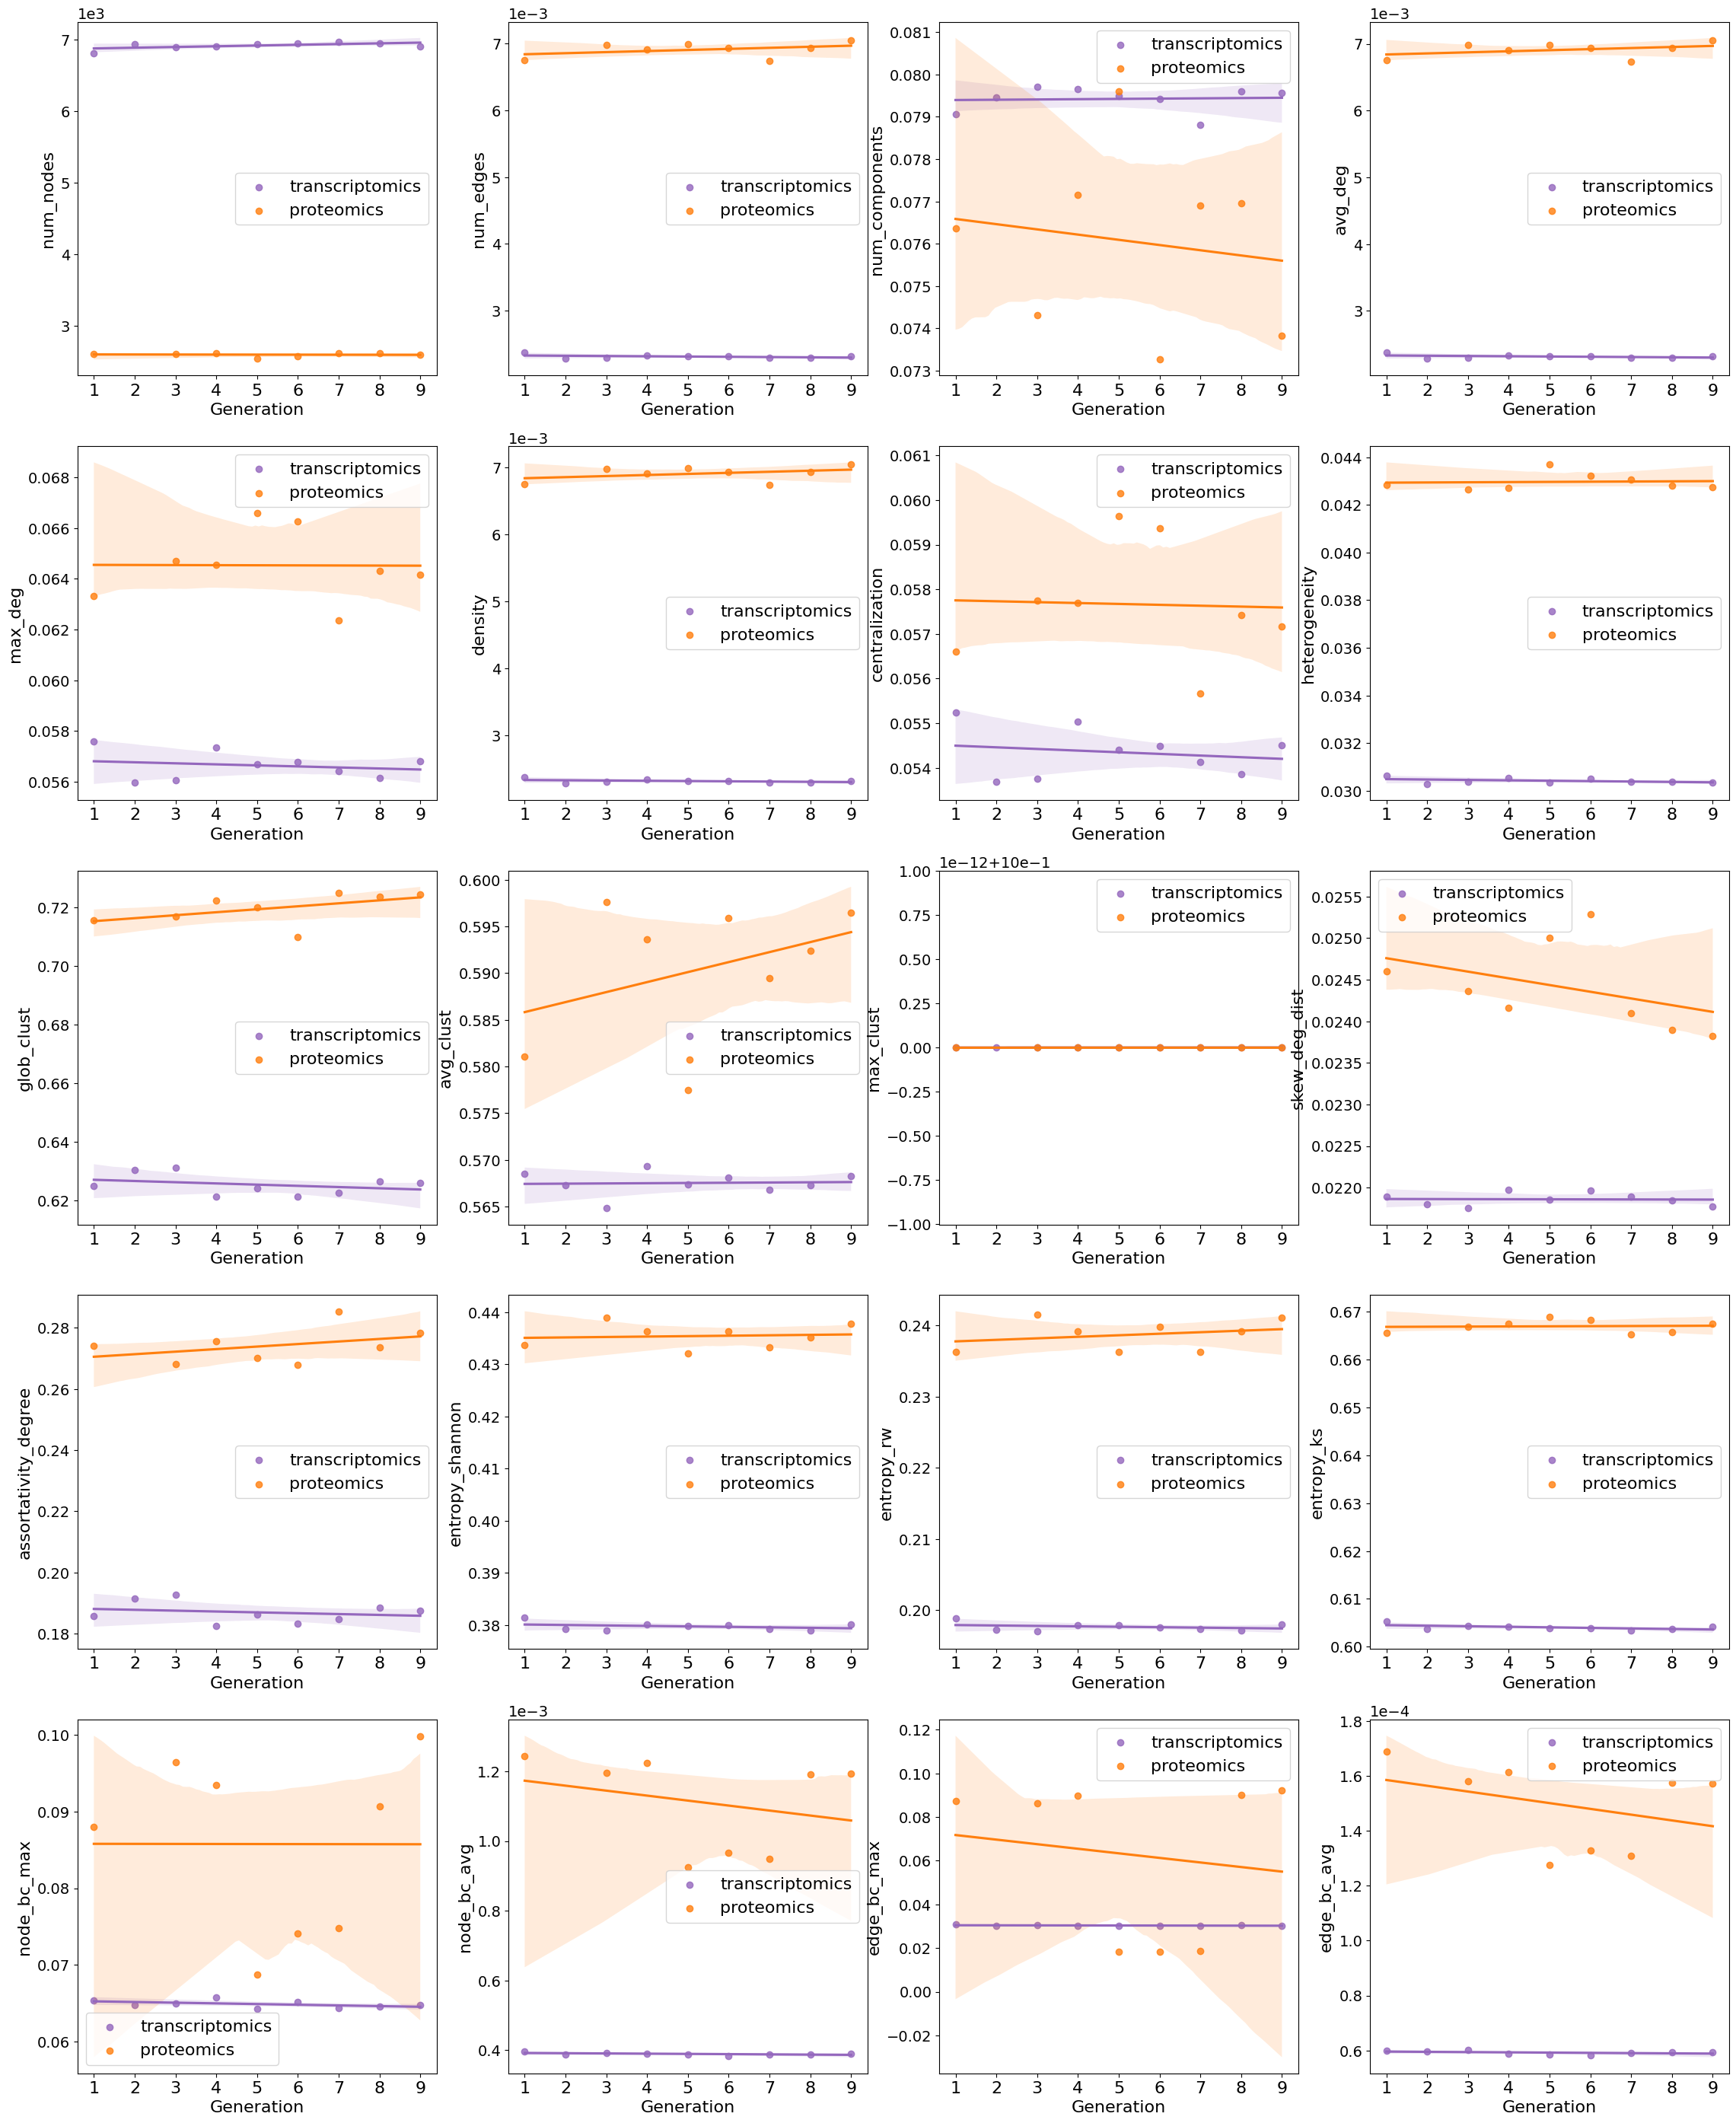

In [41]:
plt.figure(figsize=(28,35))
    
for i,metric in enumerate(metrics):
    plt.subplot(5,4,i+1)
    
    data_scaled = scale_metrics(data)
    Y = data_scaled[metric]
    X = sm.add_constant(data_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    data_slope = results.params["file_name"]
    
    data_protein_scaled = scale_metrics(data_protein)
    Y = data_protein_scaled[metric]
    X = sm.add_constant(data_protein_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    protein_slope = results.params["file_name"]
    
    ax=sns.regplot(x=data_scaled["file_name"],y=data_scaled[metric], label = "transcriptomics", color="tab:purple")
    sns.regplot(x=data_protein_scaled["file_name"],y=data_protein_scaled[metric], label = "proteomics", color="tab:orange")
    
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=14)
    plt.xlabel("Generation", fontsize=16)
    plt.ylabel(metric, fontsize=16)
    plt.legend(fontsize=16)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(-3, 3))
    ax.yaxis.offsetText.set_fontsize(14)


#plt.tight_layout()
plt.savefig("figures/cellline_scatter.pdf", bbox_inches='tight')

In [42]:
for i,metric in enumerate(metrics):
    
    data_scaled = scale_metrics(data)
    Y = data_scaled[metric]
    X = sm.add_constant(data_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    data_p = results.pvalues["file_name"]
    
    data_protein_scaled = scale_metrics(data_protein)
    Y = data_protein_scaled[metric]
    X = sm.add_constant(data_protein_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    protein_p = results.pvalues["file_name"]
    
    print(metric)
    print(data_p)
    print(protein_p)

num_nodes
0.095733158868202
0.8747956685229049
num_edges
0.3247782462935943
0.3475087932478746
num_components
0.875772399791589
0.7119976233087237
avg_deg
0.32477824629359653
0.3475087932478716
max_deg
0.6142448924292544
0.9858140515915743
density
0.32477824629361157
0.3475087932478216
centralization
0.6325883454678561
0.9244416352511913
heterogeneity
0.272729044093694
0.886447845440403
glob_clust
0.4087355738177493
0.19170070816369533
avg_clust
0.8938918452556983
0.34655748340140724
max_clust
0.29936236543738165
0.7856081739428393
skew_deg_dist
0.9332760273433882
0.3121469798714729
assortativity_degree
0.5728682187941985
0.35051980532251675
entropy_shannon
0.4154031690064137
0.8272155464666969
entropy_rw
0.45943112389507934
0.526003940366464
entropy_ks
0.09456841095550932
0.8898285998023578
node_bc_max
0.18498653599413034
0.996983674192933
node_bc_avg
0.17755775817504768
0.5057885175550842
edge_bc_max
0.24248415563702033
0.7181969750748168
edge_bc_avg
0.2583601665108966
0.398677953689

In [43]:
for i,metric in enumerate(metrics):
    
    data_scaled = scale_metrics(data)
    Y = data_scaled[metric]
    X = sm.add_constant(data_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results1 = model.fit()
    data_p = results1.pvalues["file_name"]
    
    data_protein_scaled = scale_metrics(data_protein)
    Y = data_protein_scaled[metric]
    X = sm.add_constant(data_protein_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results2 = model.fit()
    protein_p = results2.pvalues["file_name"]
    
    print(results1.params["file_name"])
    #print(round(data_p,4))
    #print(results2.params["file_name"])
    #print(round(protein_p,4))

10.166666666666998
-3.883391004098365e-06
6.626495788124992e-06
-3.883391004098365e-06
-4.07569913132076e-05
-3.883391004098202e-06
-3.6907844236712525e-05
-1.693339276292354e-05
-0.0004130950615330968
2.4506449448201406e-05
4.85722573273506e-17
-9.242605230317703e-07
-0.00027871520009109616
-9.01802724489649e-05
-6.020041008743867e-05
-0.000113671946303847
-8.883759450284065e-05
-6.65323327814976e-07
-2.6283354175961988e-05
-9.184570770291157e-08


In [44]:
for i,metric in enumerate(metrics):
    
    data_scaled = scale_metrics(data)
    Y = data_scaled[metric]
    X = sm.add_constant(data_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results1 = model.fit()
    data_p = results1.pvalues["file_name"]
    
    data_protein_scaled = scale_metrics(data_protein)
    Y = data_protein_scaled[metric]
    X = sm.add_constant(data_protein_scaled[["file_name"]])
    model = sm.OLS(Y,X)
    results2 = model.fit()
    protein_p = results2.pvalues["file_name"]
    
    #print(results1.params["file_name"])
    #print(round(data_p,4))
    print(results2.params["file_name"])
    #print(round(protein_p,4))

-0.6967418546365707
1.6031236567352523e-05
-0.00012321550946579754
1.603123656735263e-05
-3.950705597273712e-06
1.603123656735122e-05
-1.998549507970307e-05
8.01359999232391e-06
0.0010143300219711202
0.001070835335929901
2.0816681711721685e-17
-8.067227245325739e-05
0.0008316757847401431
8.184959092820757e-05
0.00021483407387310957
2.934696482533722e-05
-6.994461529894781e-06
-1.428565284263732e-05
-0.002094024086109723
-2.1052928679977418e-06


In [45]:
def test2(data1, data2, metric):
    ### test if the two lines are parallel --> values may differ, but does the trend differ too?
    aux = data1[["file_name",metric]]
    aux["group"] = [0 for i in range(len(aux))]

    aux2 = data2[["file_name",metric]]
    aux2["group"] = [1 for i in range(len(aux2))]

    aux_final = pd.concat([aux,aux2], ignore_index=True)
    aux_final["interaction"] = aux_final["file_name"]*aux_final["group"]
    
    Y = aux_final[metric]
    X = sm.add_constant(aux_final[["file_name","group","interaction"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    
    print(metric)
    print(results.summary())


In [46]:
import warnings
warnings.filterwarnings("ignore")
for metric in metrics:
    test2(scale_metrics(data),scale_metrics(data_protein),metric)

num_nodes
                            OLS Regression Results                            
Dep. Variable:              num_nodes   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.004e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           4.57e-24
Time:                        15:54:05   Log-Likelihood:                -82.887
No. Observations:                  17   AIC:                             173.8
Df Residuals:                      13   BIC:                             177.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        6862.7222     26.347    260

density
                            OLS Regression Results                            
Dep. Variable:                density   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     4863.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           4.51e-20
Time:                        15:54:05   Log-Likelihood:                 138.89
No. Observations:                  17   AIC:                            -269.8
Df Residuals:                      13   BIC:                            -266.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0023   5.69e-05     41.0

max_clust
                            OLS Regression Results                            
Dep. Variable:              max_clust   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -4.333
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               1.00
Time:                        15:54:05   Log-Likelihood:                 570.01
No. Observations:                  17   AIC:                            -1132.
Df Residuals:                      13   BIC:                            -1129.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.0000   5.51e-16   1.81

entropy_ks
                            OLS Regression Results                            
Dep. Variable:             entropy_ks   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     5263.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           2.70e-20
Time:                        15:54:05   Log-Likelihood:                 95.086
No. Observations:                  17   AIC:                            -182.2
Df Residuals:                      13   BIC:                            -178.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6046      0.001    80

In [47]:
import warnings
warnings.filterwarnings("ignore")

def test_display(data1, data2, metric):
    ### test if the two lines are parallel --> values may differ, but does the trend differ too?
    aux = data1[["file_name",metric]]
    aux["group"] = [0 for i in range(len(aux))]

    aux2 = data2[["file_name",metric]]
    aux2["group"] = [1 for i in range(len(aux2))]

    aux_final = pd.concat([aux,aux2], ignore_index=True)
    aux_final["interaction"] = aux_final["file_name"]*aux_final["group"]
    
    Y = aux_final[metric]
    X = sm.add_constant(aux_final[["file_name","group","interaction"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    
    #print(results.params["interaction"])
    print(round(results.pvalues["interaction"],4))
    
for metric in metrics:
    test_display(scale_metrics(data),scale_metrics(data_protein),metric)

0.142
0.2073
0.6681
0.2073
0.8656
0.2073
0.9347
0.6382
0.1034
0.3066
0.7791
0.2633
0.2457
0.6303
0.3839
0.4816
0.9608
0.4763
0.6911
0.3622


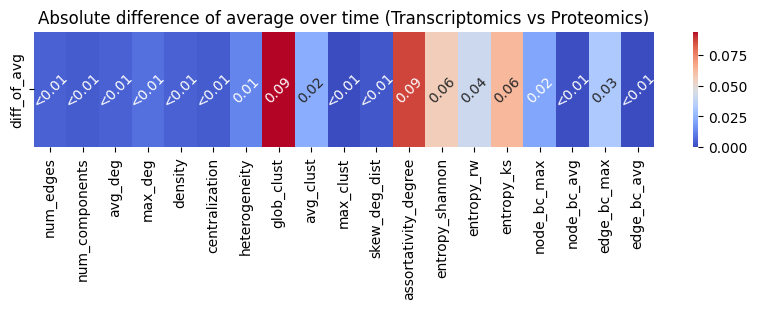

In [40]:
plt.figure(figsize=(10,1.5))
data_scaled = scale_metrics(data)
data_protein_scaled = scale_metrics(data_protein)
diffs = abs(data_scaled[metrics[1:]].mean()-data_protein_scaled[metrics[1:]].mean()).to_frame("diff_of_avg").T
labels = diffs.copy()
labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Absolute difference of average over time (Transcriptomics vs Proteomics)")
plt.savefig("figures/heatmap_overall_cellline.pdf", bbox_inches='tight')

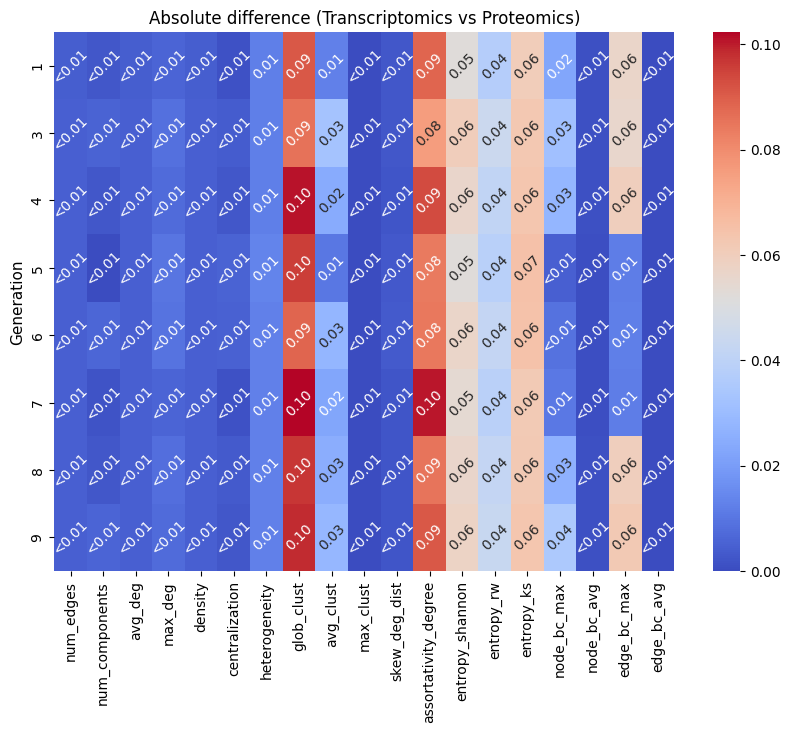

In [39]:
plt.figure(figsize=(10,7))
data_scaled = scale_metrics(data)
data_protein_scaled = scale_metrics(data_protein)
df1_aligned = data_scaled.set_index("file_name")
df2_aligned = data_protein_scaled.set_index("file_name")
df1_aligned, df2_aligned = df1_aligned.align(df2_aligned, join="inner", axis=0)

diffs = abs(df1_aligned[metrics[1:]]-df2_aligned[metrics[1:]])
labels = diffs.copy()
labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Absolute difference (Transcriptomics vs Proteomics)")
plt.ylabel("Generation", fontsize=11)
plt.savefig("figures/heatmap_time_cellline.pdf", bbox_inches='tight')

In [36]:
def random_label_switch(df, seed=0):
    g1, g2 = df["group"].unique()
    switch_map = {g1:g2, g2:g1}
    
    np.random.seed(seed)
    pair_switch = df[["file_name"]].drop_duplicates().assign(switch=lambda x:np.random.choice([True,False], size=len(x)))
    
    df = df.merge(pair_switch, on=["file_name"])
    mask = df["switch"]
    df.loc[mask, "group"] = df.loc[mask, "group"].map(switch_map)
    
    return df

def random_slope_gen(df, metric, seed):
    switched_df = random_label_switch(df, seed)
    
    Y = switched_df[switched_df["group"]==0][metric]
    X = sm.add_constant(switched_df[switched_df["group"]==0][["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    slope1 = results.params["file_name"]
    
    Y = switched_df[switched_df["group"]==1][metric]
    X = sm.add_constant(switched_df[switched_df["group"]==1][["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    slope2 = results.params["file_name"]
    
    return abs(slope1-slope2)

In [5]:
aux = scale_metrics(data)
aux["group"] = [0 for i in range(len(aux))]

aux2 = scale_metrics(data_protein)
aux2["group"] = [1 for i in range(len(aux2))]

merged_df = pd.concat([aux,aux2], ignore_index=True)

In [38]:
random_slope_diffs = {}
for metric in metrics:
    random_slope_diffs[metric] = []
    for seed in range(1000):
        slope_diff = random_slope_gen(merged_df, metric, seed)
        random_slope_diffs[metric].append(slope_diff)

In [39]:
for metric in metrics:
    Y = merged_df[merged_df["group"]==0][metric]
    X = sm.add_constant(merged_df[merged_df["group"]==0][["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    slope1 = results.params["file_name"]
    
    Y = merged_df[merged_df["group"]==1][metric]
    X = sm.add_constant(merged_df[merged_df["group"]==1][["file_name"]])
    model = sm.OLS(Y,X)
    results = model.fit()
    slope2 = results.params["file_name"]
    
    null = abs(slope1-slope2)
    
    count = len([x for x in random_slope_diffs[metric] if x < null])
    pvalue = count/1000
    print(metric, pvalue)

num_nodes 0.02
num_edges 0.023
num_components 0.181
avg_deg 0.023
max_deg 0.039
density 0.023
centralization 0.032
heterogeneity 0.012
glob_clust 0.103
avg_clust 0.254
max_clust 0.0
skew_deg_dist 0.198
assortativity_degree 0.075
entropy_shannon 0.025
entropy_rw 0.053
entropy_ks 0.005
node_bc_max 0.022
node_bc_avg 0.102
edge_bc_max 0.213
edge_bc_avg 0.116


The null hypothesis that the observed differences are larger than the random can be rejected for 11 metrics, but not for 9 metrics.

(We want: in less than 5% of the cases the observed is larger than the random.)

In [58]:
data["num_nodes"].mean(), data_protein["num_nodes"].mean()

(6913.555555555556, 2593.25)

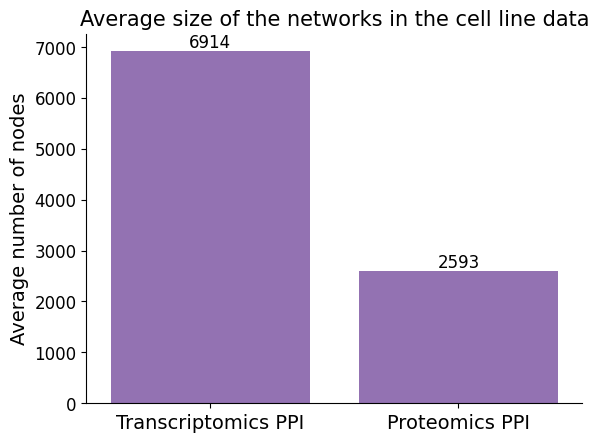

In [2]:
ax=sns.barplot(x=["Transcriptomics PPI","Proteomics PPI"], y = [6914, 2593], color="tab:purple")
ax.bar_label(ax.containers[0], fontsize=12);
plt.ylabel("Average number of nodes", fontsize=14)
plt.yticks(fontsize=12)
plt.xticks(fontsize=14)
sns.despine()
plt.title("Average size of the networks in the cell line data", fontsize=15)
plt.savefig("figures/avg_size_cell_line.pdf", bbox_inches='tight')

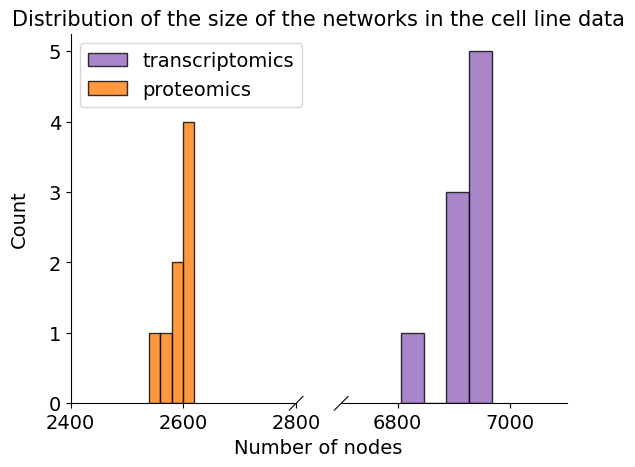

In [27]:
from brokenaxes import brokenaxes

bax = brokenaxes(xlims=((2400, 2800), (6700, 7100)))
bax.hist(x=merged_df[merged_df["group"]==0]["num_nodes"], bins=4, color="tab:purple", label="transcriptomics", edgecolor="black", alpha=0.8)
bax.hist(x=merged_df[merged_df["group"]==1]["num_nodes"], bins=4, color="tab:orange", label="proteomics", edgecolor="black", alpha=0.8)
for ax in bax.axs:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
bax.set_xlabel("Number of nodes", fontsize=14, labelpad=25)
bax.set_ylabel("Count", fontsize=14)
bax.legend(fontsize=14, loc=2)
plt.title("Distribution of the size of the networks in the cell line data", fontsize=15)
plt.savefig("figures/distr_size_cell_line.pdf", bbox_inches='tight')

In [6]:
data["num_nodes"].min(), data["num_nodes"].max()

(6806, 6967)

In [7]:
data_protein["num_nodes"].min(), data_protein["num_nodes"].max()

(2539, 2619)